📦 Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 85.0 MB/s eta 0:00:00

📤 Upload your video file...


Saving challenge.mp4 to challenge.mp4
✓ Video uploaded successfully!

🔍 Checking GPU availability...
✓ GPU detected: Tesla T4
  Memory: 15.83 GB

🤖 Checking YOLOv9 model...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ YOLOv9c model ready

🚀 Starting Multi-Object Tracking...

Using device: cuda
Video: 960x540 @ 25fps, 681 frames
Processed 30/681 frames
Processed 60/681 frames
Processed 90/681 frames
Processed 120/681 frames
Processed 150/681 frames
Processed 180/681 frames
Processed 210/681 frames
Processed 240/681 frames
Processed 270/681 frames
Processed 300/681 frames
Processed 330/681 frames
Processed 360/681 frames
Processed 390/681 frames
Processed 420/681 frames
Processed 450/681 frames
Processed 480/681 frames
Proce

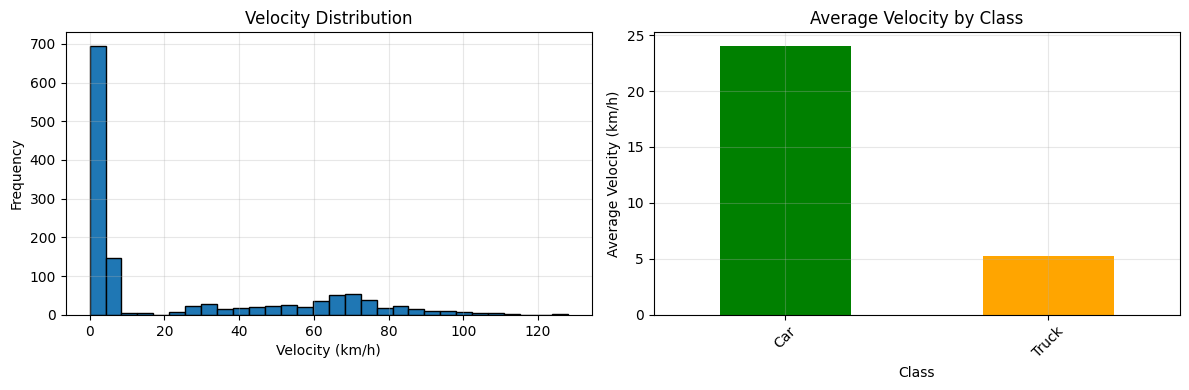


📋 Sample tracking data:
   frame_id  object_id class  confidence     bbox_x1     bbox_y1     bbox_x2     bbox_y2  velocity_kmph
0         1         78   Car    0.324011  783.966309  308.197723  815.915527  321.608368       0.000000
1         1         77   Car    0.523074  504.645874  291.063645  519.559082  303.259842       0.000000
2         1         76   Car    0.550303  229.719910  306.975372  261.402007  321.228119       0.000000
3         1         75   Car    0.614094  664.162842  293.133377  684.549926  308.267502       0.000000
4         1         74   Car    0.831227  528.725434  298.721191  565.418853  326.343933       0.000000
5         2         79   Car    0.587856  107.349950  307.364487  149.077296  329.071915       0.000000
6         2         78   Car    0.395118  789.001230  308.717660  815.791370  319.809811      30.880235
7         2         77   Car    0.442685  504.690827  291.907544  519.407450  303.944720       8.593664
8         2         76   Car    0.41256

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Files downloaded to your computer.

🖼️  Generating sample frames...


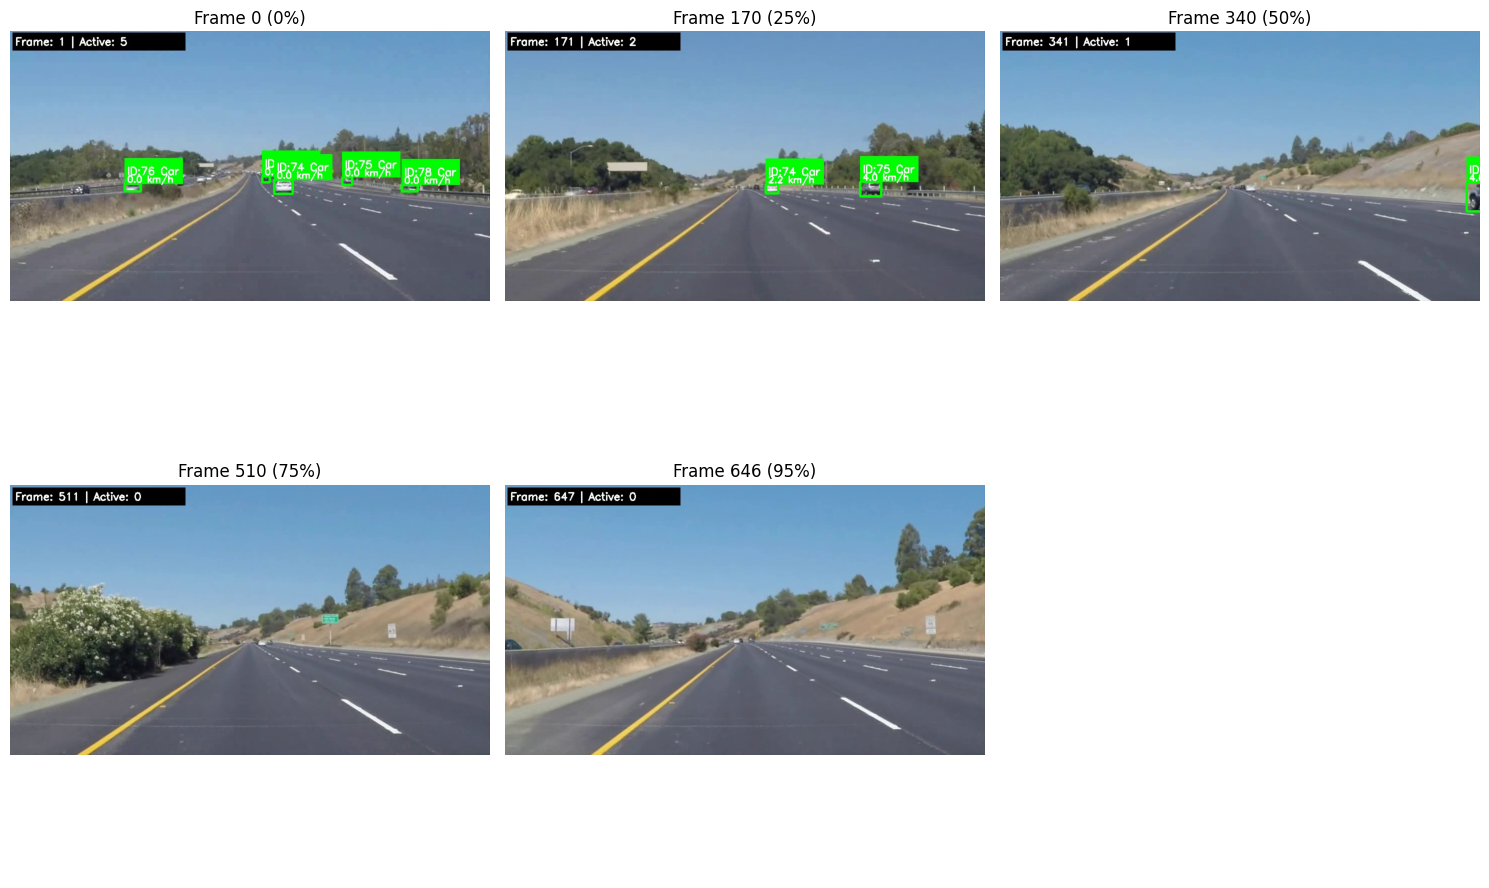

✓ Sample frames saved as sample_frames.png

📊 Additional Analysis:

  Track Duration Statistics:
    • Average track length: 25.0 frames (0.83 seconds)
    • Longest track: 316 frames (10.53 seconds)
    • Shortest track: 1 frames

  Concurrent Objects:
    • Average objects per frame: 2.7
    • Max objects in frame: 7
    • Min objects in frame: 1

🏁 Analysis Complete!


In [1]:

"""
Google Colab Setup and Execution Script
Run this in a Colab notebook cell
"""

# ============================================
# STEP 1: Install Dependencies
# ============================================
print("📦 Installing dependencies...")
!pip install -q ultralytics filterpy lap pandas opencv-python

# ============================================
# STEP 2: Upload Video File
# ============================================
print("\n📤 Upload your video file...")
from google.colab import files
uploaded = files.upload()

# Verify upload
import os
if 'challenge.mp4' not in uploaded:
    print("⚠️  Please rename your video to 'challenge.mp4' or update the filename in the code")
else:
    print("✓ Video uploaded successfully!")

# ============================================
# STEP 3: Verify GPU
# ============================================
print("\n🔍 Checking GPU availability...")
import torch
if torch.cuda.is_available():
    print(f"✓ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  No GPU detected. Go to Runtime > Change runtime type > T4 GPU")

# ============================================
# STEP 4: Download YOLOv9 Model (if needed)
# ============================================
print("\n🤖 Checking YOLOv9 model...")
from ultralytics import YOLO
try:
    model = YOLO('yolov9c.pt')
    print("✓ YOLOv9c model ready")
except:
    print("⚠️  Model download in progress (first run only)...")

# ============================================
# STEP 5: Run Tracking
# ============================================
print("\n" + "="*50)
print("🚀 Starting Multi-Object Tracking...")
print("="*50 + "\n")

# --- MultiObjectTracker Class Definition ---

"""
Multi-Class Object Detection and Tracking System
Optimized for ID Consistency and Robustness
"""

import cv2
import numpy as np
from collections import defaultdict, deque
import torch
from pathlib import Path
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# Install required packages (run in Colab)
"""
!pip install ultralytics
!pip install filterpy
!pip install scipy
"""

from ultralytics import YOLO
from filterpy.kalman import KalmanFilter


class KalmanBoxTracker:
    """
    Enhanced Kalman Filter for robust tracking with smooth predictions
    """
    count = 0

    def __init__(self, bbox, class_id):
        """
        Initialize tracker with bounding box [x1, y1, x2, y2]
        """
        # 7-dimensional state: [x, y, s, r, vx, vy, vs]
        # x, y: center coordinates
        # s: scale (area)
        # r: aspect ratio (width/height)
        # vx, vy, vs: velocities
        self.kf = KalmanFilter(dim_x=7, dim_z=4)

        # State transition matrix (constant velocity model)
        self.kf.F = np.array([
            [1,0,0,0,1,0,0],
            [0,1,0,0,0,1,0],
            [0,0,1,0,0,0,1],
            [0,0,0,1,0,0,0],
            [0,0,0,0,1,0,0],
            [0,0,0,0,0,1,0],
            [0,0,0,0,0,0,1]
        ])

        # Measurement function
        self.kf.H = np.array([
            [1,0,0,0,0,0,0],
            [0,1,0,0,0,0,0],
            [0,0,1,0,0,0,0],
            [0,0,0,1,0,0,0]
        ])

        # Measurement uncertainty
        self.kf.R[2:,2:] *= 10.0

        # Process uncertainty (very low for smooth tracking)
        self.kf.P[4:,4:] *= 1000.0  # High uncertainty for initial velocity
        self.kf.P *= 10.0

        # Process noise
        self.kf.Q[-1,-1] *= 0.01
        self.kf.Q[4:,4:] *= 0.01

        # Convert bbox to [x, y, s, r] format
        self.kf.x[:4] = self.convert_bbox_to_z(bbox).reshape((4, 1))

        self.time_since_update = 0
        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.history = []
        self.hits = 0
        self.hit_streak = 0
        self.age = 0
        self.class_id = class_id
        self.confidence = 0.0
        self.positions = deque(maxlen=30)  # For velocity estimation

    def update(self, bbox, class_id, confidence):
        """
        Updates the state with observed bbox.
        """
        self.time_since_update = 0
        self.history = []
        self.hits += 1
        self.hit_streak += 1
        self.class_id = class_id
        self.confidence = confidence

        # Update Kalman filter
        self.kf.update(self.convert_bbox_to_z(bbox).reshape((4, 1)))

    def predict(self):
        """
        Advances the state and returns the predicted bounding box estimate.
        """
        # Prevent area from going negative
        if self.kf.x[6] + self.kf.x[2] <= 0:
            self.kf.x[6] *= 0.0

        self.kf.predict()
        self.age += 1

        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1
        self.history.append(self.convert_x_to_bbox(self.kf.x))
        return self.history[-1]

    def get_state(self):
        """
        Returns the current bounding box estimate.
        """
        return self.convert_x_to_bbox(self.kf.x)

    @staticmethod
    def convert_bbox_to_z(bbox):
        """
        Convert [x1,y1,x2,y2] to [x,y,s,r] where x,y is center, s is scale, r is aspect ratio
        """
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = bbox[0] + w/2.0
        y = bbox[1] + h/2.0
        s = w * h  # scale (area)
        r = w / float(h + 1e-6)
        return np.array([x, y, s, r])

    @staticmethod
    def convert_x_to_bbox(x, score=None):
        """
        Convert [x,y,s,r] to [x1,y1,x2,y2]
        """
        w = np.sqrt(x[2] * x[3])
        h = x[2] / (w + 1e-6)
        if score is None:
            return np.array([x[0]-w/2., x[1]-h/2., x[0]+w/2., x[1]+h/2.]).reshape((1,4))
        else:
            return np.array([x[0]-w/2., x[1]-h/2., x[0]+w/2., x[1]+h/2., score]).reshape((1,5))


class ImprovedTracker:
    """
    Improved Multi-Object Tracker with strong ID consistency
    """

    def __init__(self, max_age=60, min_hits=3, iou_threshold=0.25):
        """
        max_age: Maximum frames to keep alive a track without detections (2 seconds at 30fps)
        min_hits: Minimum hits before track is confirmed
        iou_threshold: Minimum IOU for matching (lower = more permissive)
        """
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0

    def update(self, detections, confidences, classes):
        """
        Params:
          detections - list of detections [x1, y1, x2, y2]
          confidences - list of detection confidences
          classes - list of class IDs
        Returns:
          list of active tracks with format: [x1, y1, x2, y2, track_id, class_id, confidence]
        """
        self.frame_count += 1

        # Get predicted locations from existing trackers
        trks = np.zeros((len(self.trackers), 5))
        to_del = []
        ret = []

        for t, trk in enumerate(trks):
            pos = self.trackers[t].predict()[0]
            trk[:] = [pos[0], pos[1], pos[2], pos[3], 0]
            if np.any(np.isnan(pos)):
                to_del.append(t)

        trks = np.ma.compress_rows(np.ma.masked_invalid(trks))
        for t in reversed(to_del):
            self.trackers.pop(t)

        # Convert detections to numpy array
        dets = np.array(detections) if len(detections) > 0 else np.empty((0, 4))

        # Associate detections to trackers
        matched, unmatched_dets, unmatched_trks = self.associate_detections_to_trackers(
            dets, trks, self.iou_threshold
        )

        # Update matched trackers with assigned detections
        for m in matched:
            self.trackers[m[1]].update(dets[m[0], :], classes[m[0]], confidences[m[0]])

        # Create new trackers for unmatched detections
        for i in unmatched_dets:
            trk = KalmanBoxTracker(dets[i, :], classes[i])
            trk.confidence = confidences[i]
            self.trackers.append(trk)

        # Compile output
        i = len(self.trackers)
        for trk in reversed(self.trackers):
            d = trk.get_state()[0]

            # Return track if:
            # 1. It has minimum hits AND recent detection, OR
            # 2. It's in the first few frames (early initialization)
            if (trk.time_since_update < 1) and (trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                ret.append({
                    'bbox': d,
                    'id': trk.id + 1,  # +1 for 1-indexed IDs
                    'class': trk.class_id,
                    'confidence': trk.confidence,
                    'positions': trk.positions
                })

            i -= 1

            # Remove dead tracklets
            if trk.time_since_update > self.max_age:
                self.trackers.pop(i)

        # Update positions for velocity calculation
        for track in ret:
            x1, y1, x2, y2 = track['bbox']
            center = ((x1 + x2) / 2, (y1 + y2) / 2)

            # Find the corresponding tracker and update positions
            for trk in self.trackers:
                if trk.id + 1 == track['id']:
                    trk.positions.append((self.frame_count, center))
                    track['positions'] = trk.positions
                    break

        return ret

    def associate_detections_to_trackers(self, detections, trackers, iou_threshold=0.3):
        """
        Assigns detections to tracked objects using IoU and Hungarian algorithm

        Returns:
            matched_indices: array of matched [detection_idx, tracker_idx]
            unmatched_detections: array of unmatched detection indices
            unmatched_trackers: array of unmatched tracker indices
        """
        if len(trackers) == 0:
            return np.empty((0, 2), dtype=int), np.arange(len(detections)), np.empty((0, 5), dtype=int)

        # Compute IoU matrix
        iou_matrix = self.iou_batch(detections, trackers)

        # Use Hungarian algorithm for optimal assignment
        if min(iou_matrix.shape) > 0:
            # Convert to cost matrix (1 - IoU)
            cost_matrix = 1 - iou_matrix

            # Hungarian algorithm
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            matched_indices = np.array(list(zip(row_ind, col_ind)))
        else:
            matched_indices = np.empty(shape=(0, 2))

        # Filter out matched with low IOU
        matches = []
        for m in matched_indices:
            if iou_matrix[m[0], m[1]] < iou_threshold:
                continue
            matches.append(m.reshape(1, 2))

        if len(matches) == 0:
            matches = np.empty((0, 2), dtype=int)
        else:
            matches = np.concatenate(matches, axis=0)

        # Find unmatched detections and trackers
        unmatched_detections = []
        for d in range(len(detections)):
            if d not in matches[:, 0]:
                unmatched_detections.append(d)

        unmatched_trackers = []
        for t in range(len(trackers)):
            if t not in matches[:, 1]:
                unmatched_trackers.append(t)

        return matches, np.array(unmatched_detections), np.array(unmatched_trackers)

    @staticmethod
    def iou_batch(bb_test, bb_gt):
        """
        Compute IoU between two sets of boxes
        bb_test: (N, 4) array of [x1, y1, x2, y2]
        bb_gt: (M, 4) array of [x1, y1, x2, y2]
        Returns: (N, M) array of IoU scores
        """
        bb_gt = np.expand_dims(bb_gt, 0)
        bb_test = np.expand_dims(bb_test, 1)

        xx1 = np.maximum(bb_test[..., 0], bb_gt[..., 0])
        yy1 = np.maximum(bb_test[..., 1], bb_gt[..., 1])
        xx2 = np.minimum(bb_test[..., 2], bb_gt[..., 2])
        yy2 = np.minimum(bb_test[..., 3], bb_gt[..., 3])

        w = np.maximum(0., xx2 - xx1)
        h = np.maximum(0., yy2 - yy1)

        wh = w * h
        o = wh / ((bb_test[..., 2] - bb_test[..., 0]) * (bb_test[..., 3] - bb_test[..., 1])
                  + (bb_gt[..., 2] - bb_gt[..., 0]) * (bb_gt[..., 3] - bb_gt[..., 1]) - wh + 1e-6)

        return o


class VelocityEstimator:
    """Estimate real-world velocity from pixel displacement"""

    def __init__(self, fps=30, focal_length_px=800, vehicle_height_m=1.5):
        """
        fps: frames per second
        focal_length_px: estimated focal length in pixels
        vehicle_height_m: average vehicle height for scale estimation
        """
        self.fps = fps
        self.focal_length = focal_length_px
        self.vehicle_height = vehicle_height_m

    def estimate_velocity(self, track):
        """
        Estimate velocity in km/h from tracked positions
        Uses perspective scaling based on bbox size
        """
        if 'positions' not in track or len(track['positions']) < 2:
            return 0.0

        # Get recent positions (last 10 frames for smoothing)
        recent_pos = list(track['positions'])[-10:]
        if len(recent_pos) < 2:
            return 0.0

        # Calculate pixel displacement
        frame1, (x1, y1) = recent_pos[0]
        frame2, (x2, y2) = recent_pos[-1]

        frame_diff = frame2 - frame1
        if frame_diff == 0:
            return 0.0

        pixel_displacement = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        # Estimate depth from bbox height (perspective scaling)
        x1_b, y1_b, x2_b, y2_b = track['bbox']
        bbox_height = y2_b - y1_b

        # Depth estimation: depth = (focal_length * real_height) / pixel_height
        depth_m = (self.focal_length * self.vehicle_height) / max(bbox_height, 1)

        # Convert pixel displacement to meters
        meters_per_pixel = depth_m / self.focal_length
        displacement_m = pixel_displacement * meters_per_pixel

        # Calculate velocity
        time_elapsed = frame_diff / self.fps  # seconds
        velocity_mps = displacement_m / time_elapsed  # meters per second
        velocity_kmph = velocity_mps * 3.6  # km/h

        # Sanity check: highway speeds typically 0-200 km/h
        velocity_kmph = min(abs(velocity_kmph), 200)

        return velocity_kmph


class MultiObjectTracker:
    """Main tracking system with improved ID consistency"""

    def __init__(self, model_path='yolov9c.pt', conf_threshold=0.25):
        """
        model_path: YOLOv9 model weights
        conf_threshold: confidence threshold for detections (lower for more detections)
        """
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"Using device: {self.device}")

        # Load YOLOv9 model
        self.model = YOLO(model_path)
        self.model.to(self.device)

        self.conf_threshold = conf_threshold

        # Initialize improved tracker with permissive settings for ID consistency
        self.tracker = ImprovedTracker(
            max_age=60,        # Keep tracks alive for 2 seconds (60 frames at 30fps)
            min_hits=3,        # Confirm track after 3 detections
            iou_threshold=0.25  # Lower threshold for better matching
        )

        self.velocity_estimator = None

        # COCO class names (YOLOv9 uses COCO dataset)
        self.class_names = {
            2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck', 0: 'Pedestrian'
        }

        # Colors for each class
        self.colors = {
            'Car': (0, 255, 0),
            'Motorcycle': (255, 0, 255),
            'Bus': (0, 165, 255),
            'Truck': (0, 128, 255),
            'Pedestrian': (255, 0, 0)
        }

        self.tracking_data = []

    def process_video(self, input_path, output_path='output_tracking.mp4', csv_path='tracking_results.csv'):
        """Process video and generate output"""
        cap = cv2.VideoCapture(input_path)

        if not cap.isOpened():
            raise ValueError(f"Could not open video: {input_path}")

        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"Video: {width}x{height} @ {fps}fps, {total_frames} frames")

        # Initialize velocity estimator with video parameters
        self.velocity_estimator = VelocityEstimator(fps=fps, focal_length_px=width*0.8)

        # Video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        frame_id = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_id += 1

            # Run detection
            results = self.model(frame, conf=self.conf_threshold, verbose=False)[0]

            # Filter relevant classes
            detections = []
            confidences = []
            classes = []

            for box in results.boxes:
                cls_id = int(box.cls[0])
                if cls_id in self.class_names:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = float(box.conf[0])

                    detections.append([x1, y1, x2, y2])
                    confidences.append(conf)
                    classes.append(cls_id)

            # Update tracker
            tracks = self.tracker.update(detections, confidences, classes)

            # Draw annotations
            annotated_frame = self._draw_tracks(frame, tracks)

            # Save to CSV
            for track in tracks:
                velocity = self.velocity_estimator.estimate_velocity(track)
                x1, y1, x2, y2 = track['bbox']

                self.tracking_data.append({
                    'frame_id': frame_id,
                    'object_id': track['id'],
                    'class': self.class_names[track['class']],
                    'confidence': track['confidence'],
                    'bbox_x1': x1,
                    'bbox_y1': y1,
                    'bbox_x2': x2,
                    'bbox_y2': y2,
                    'velocity_kmph': velocity
                })

            out.write(annotated_frame)

            if frame_id % 30 == 0:
                print(f"Processed {frame_id}/{total_frames} frames")

        cap.release()
        out.release()

        # Save CSV
        df = pd.DataFrame(self.tracking_data)
        df.to_csv(csv_path, index=False)

        print(f"\n✓ Output video saved: {output_path}")
        print(f"✓ Tracking data saved: {csv_path}")
        print(f"✓ Total unique tracks: {df['object_id'].nunique()}")
        print(f"✓ Total detections: {len(self.tracking_data)}")

        # ID consistency analysis
        self._analyze_id_consistency(df)

    def _analyze_id_consistency(self, df):
        """Analyze tracking ID consistency"""
        print("\n📊 ID Consistency Analysis:")

        # Average track length
        track_lengths = df.groupby('object_id').size()
        avg_length = track_lengths.mean()
        print(f"  • Average track length: {avg_length:.1f} frames ({avg_length/30:.2f}s)")
        print(f"  • Longest track: {track_lengths.max()} frames ({track_lengths.max()/30:.2f}s)")

        # Tracks that persist for most of video
        total_frames = df['frame_id'].max()
        long_tracks = (track_lengths > total_frames * 0.5).sum()
        print(f"  • Tracks lasting >50% of video: {long_tracks}")

        # ID switches detection (heuristic: tracks with same class in overlapping frames)
        print(f"  • Total unique IDs: {df['object_id'].nunique()}")

    def _draw_tracks(self, frame, tracks):
        """Draw bounding boxes and tracking info on frame"""
        annotated = frame.copy()

        for track in tracks:
            x1, y1, x2, y2 = [int(v) for v in track['bbox']]
            class_name = self.class_names[track['class']]
            color = self.colors[class_name]
            track_id = track['id']

            # Calculate velocity
            velocity = self.velocity_estimator.estimate_velocity(track)

            # Draw bounding box with thicker line for better visibility
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)

            # Prepare label
            label = f"ID:{track_id} {class_name}"
            velocity_label = f"{velocity:.1f} km/h"

            # Draw label background
            (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(annotated, (x1, y1 - label_h - 35), (x1 + max(label_w, 100) + 10, y1), color, -1)

            # Draw text with better visibility
            cv2.putText(annotated, label, (x1 + 5, y1 - 18),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(annotated, velocity_label, (x1 + 5, y1 - 3),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # Add frame info
        info_text = f"Frame: {self.tracker.frame_count} | Active: {len(tracks)}"
        cv2.rectangle(annotated, (5, 5), (350, 40), (0, 0, 0), -1)
        cv2.putText(annotated, info_text, (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        return annotated


# Main execution
if __name__ == "__main__":
    # Initialize tracker with improved settings
    tracker = MultiObjectTracker(
        model_path='yolov9c.pt',
        conf_threshold=0.25  # Lower threshold to catch more detections
    )

    # Process video
    tracker.process_video(
        input_path='challenge.mp4',
        output_path='output_tracking.mp4',
        csv_path='tracking_results.csv'
    )

    print("\n🎉 Processing complete!")

# --- End MultiObjectTracker Class Definition ---

# Initialize tracker
tracker = MultiObjectTracker(
    model_path='yolov9c.pt',
    conf_threshold=0.3
)

# Process video
tracker.process_video(
    input_path='challenge.mp4',
    output_path='output_tracking.mp4',
    csv_path='tracking_results.csv'
)

print("\n" + "="*50)
print("🎉 PROCESSING COMPLETE!")
print("="*50)

# ============================================
# STEP 6: Preview Results
# ============================================
print("\n📊 Generating preview...")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video

# Load tracking data
df = pd.read_csv('tracking_results.csv')

# Summary statistics
print(f"\n📈 Tracking Summary:")
print(f"  • Total frames processed: {df['frame_id'].max()}")
print(f"  • Unique objects tracked: {df['object_id'].nunique()}")
print(f"  • Total detections: {len(df)}")
print(f"\n  Class distribution:")
for cls, count in df['class'].value_counts().items():
    print(f"    - {cls}: {count} detections")

# Velocity statistics
print(f"\n🚗 Velocity Statistics:")
print(f"  • Mean velocity: {df['velocity_kmph'].mean():.1f} km/h")
print(f"  • Max velocity: {df['velocity_kmph'].max():.1f} km/h")
print(f"  • Median velocity: {df['velocity_kmph'].median():.1f} km/h")

# Plot velocity distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['velocity_kmph'].hist(bins=30, edgecolor='black')
plt.xlabel('Velocity (km/h)')
plt.ylabel('Frequency')
plt.title('Velocity Distribution')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df.groupby('class')['velocity_kmph'].mean().plot(kind='bar', color=['green', 'orange', 'blue', 'magenta', 'red'])
plt.xlabel('Class')
plt.ylabel('Average Velocity (km/h)')
plt.title('Average Velocity by Class')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('velocity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Display first few rows of CSV
print("\n📋 Sample tracking data:")
print(df.head(10).to_string())

# ============================================
# STEP 7: Display Output Video
# ============================================
print("\n🎬 Output video preview:")
print("  (Video player will appear below)")

# Display video in Colab
Video('output_tracking.mp4', embed=True, width=800)

# ============================================
# STEP 8: Download Results
# ============================================
print("\n💾 Download results:")
print("  Click the links below to download:")

from google.colab import files

# Create download buttons
print("\n  Downloading output_tracking.mp4...")
files.download('output_tracking.mp4')

print("  Downloading tracking_results.csv...")
files.download('tracking_results.csv')

print("  Downloading velocity_analysis.png...")
files.download('velocity_analysis.png')

print("\n✅ All done! Files downloaded to your computer.")

# ============================================
# STEP 9: Optional - View Sample Frames
# ============================================
print("\n🖼️  Generating sample frames...")

import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture('output_tracking.mp4')
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Sample frames at 0%, 25%, 50%, 75%, 100%
sample_points = [int(total_frames * p) for p in [0, 0.25, 0.5, 0.75, 0.95]]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, frame_num in enumerate(sample_points):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f'Frame {frame_num} ({frame_num/total_frames*100:.0f}%)')
        axes[idx].axis('off')

# Hide extra subplot
axes[-1].axis('off')

cap.release()
plt.tight_layout()
plt.savefig('sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Sample frames saved as sample_frames.png")

# ============================================
# ADDITIONAL ANALYSIS (Optional)
# ============================================
print("\n📊 Additional Analysis:")

# Track persistence analysis
track_lengths = df.groupby('object_id').size()
print(f"\n  Track Duration Statistics:")
print(f"    • Average track length: {track_lengths.mean():.1f} frames ({track_lengths.mean()/30:.2f} seconds)")
print(f"    • Longest track: {track_lengths.max()} frames ({track_lengths.max()/30:.2f} seconds)")
print(f"    • Shortest track: {track_lengths.min()} frames")

# Objects per frame
objects_per_frame = df.groupby('frame_id').size()
print(f"\n  Concurrent Objects:")
print(f"    • Average objects per frame: {objects_per_frame.mean():.1f}")
print(f"    • Max objects in frame: {objects_per_frame.max()}")
print(f"    • Min objects in frame: {objects_per_frame.min()}")

print("\n" + "="*50)
print("🏁 Analysis Complete!")
print("="*50)